<a href="https://colab.research.google.com/github/masonstephen/AI-Coursework--2025/blob/main/Pokemon_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# This cell sets up the environment by importing necessary libraries.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from google.colab import files
import io

# Set a random seed for reproducibility
np.random.seed(42)

print("Setup Complete.")


Setup Complete.


In [11]:
# This cell handles file upload and performs the initial data cleaning.

print("--- Data Cleaning ---")

# Uploading the Pokemon file
print("Please upload the 'Pokemon.csv' file.")
uploaded = files.upload()

# Read the uploaded file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"Successfully loaded {file_name}. Initial shape: {df.shape}")

# 1. Drop unnecessary columns: 'SN' and 'Name'
# The original dataset has an unnamed index column, which we will also drop if it exists.
if 'SN' in df.columns:
    df = df.drop(columns=['SN'])
if df.columns[0] == 'SN':
    df = df.drop(df.columns[0], axis=1)

# 2. Handle missing values in 'Type 2' by filling with 'None'
# Missing values in 'Type 2' are represented by NaN or empty strings.
df['Type 2'] = df['Type 2'].replace(np.nan, 'None').replace('', 'None')

# 3. Convert 'Legendary' to a numerical target variable (0 or 1)
# This is crucial for classification models.
df['Legendary'] = df['Legendary'].astype(int)

# 4. Create the 'Total' stat column, which is useful for EDA and modeling
df['Total'] = df[['HP', 'Attack', 'Defense', 'Sp. Attack', 'Sp. Defense', 'Speed']].sum(axis=1)

# Drop the 'Name' column as it's not a feature for the model.
df_cleaned = df.drop(columns=['Name'])

print(f"\nCleaned dataset shape: {df_cleaned.shape}")
print("Data Cleaning Complete.")


--- Data Cleaning ---
Please upload the 'Pokemon.csv' file.


Saving Pokemon.csv to Pokemon (1).csv
Successfully loaded Pokemon (1).csv. Initial shape: (800, 12)

Cleaned dataset shape: (800, 11)
Data Cleaning Complete.



--- Exploratory Data Analysis (EDA) ---

Insight 1: Legendary Pokemon Distribution (Target Variable Balance)
Observation: The dataset is highly imbalanced. Only 65 out of 800 Pokemon are Legendary (approx. 8.12%).


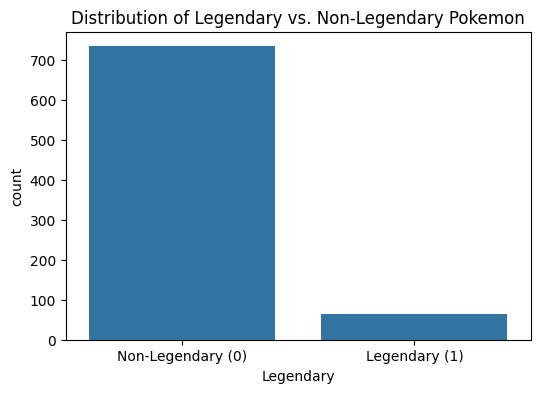


Insight 2: Legendary Pokemon have significantly higher Total Stats.
Observation: Legendary Pokemon have an average Total Stat of 637.38, which is much higher than Non-Legendary Pokemon's average of 417.21.


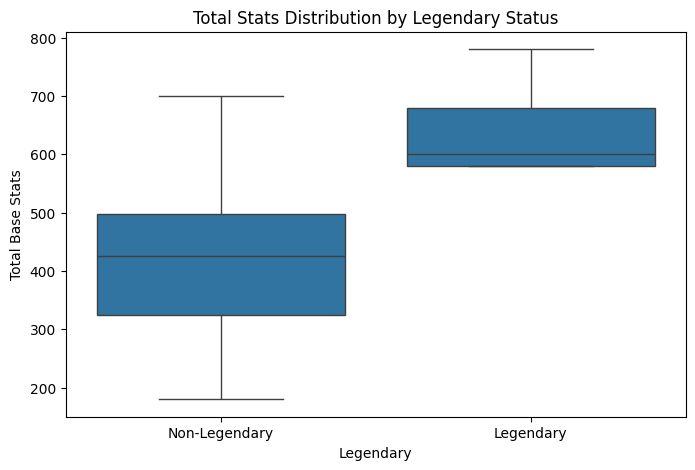


Insight 3: Legendary Pokemon are not evenly distributed across Generations.
Observation: Generation 3 has the highest proportion of Legendary Pokemon (11.25%).


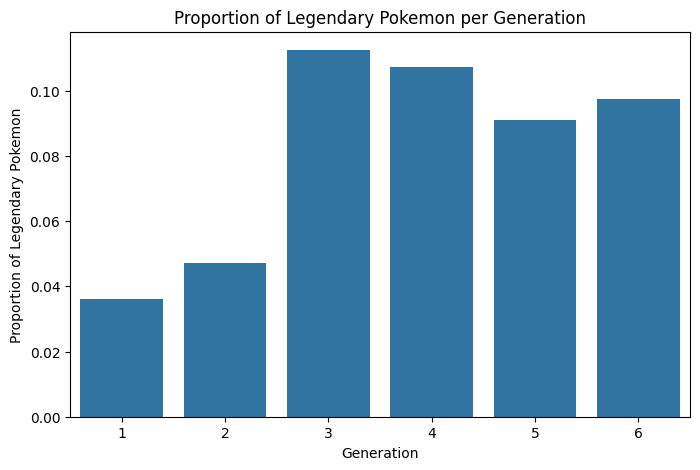


Insight 4: Certain Pokemon Types are more likely to be Legendary.
Observation: The top type is 'Flying' with a Legendary Ratio of 50.00%.


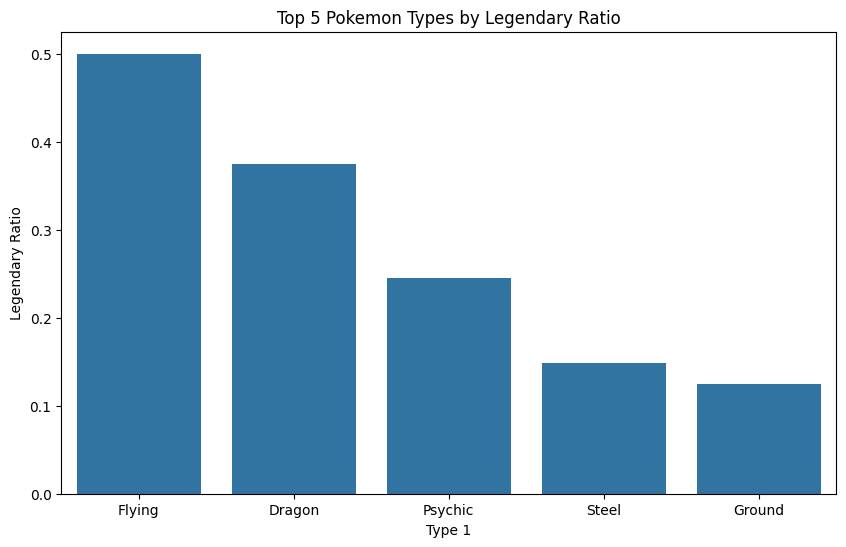


Exploratory Data Analysis Complete.


In [12]:
# EDA and retrieves at least 4 insights/observations.

print("\n--- Exploratory Data Analysis (EDA) ---")

# 1. Insight: Legendary Pokemon Distribution (Target Variable Balance)
legendary_counts = df_cleaned['Legendary'].value_counts()
print("\nInsight 1: Legendary Pokemon Distribution (Target Variable Balance)")
print(f"Observation: The dataset is highly imbalanced. Only {legendary_counts[1]} out of {len(df_cleaned)} Pokemon are Legendary (approx. {legendary_counts[1]/len(df_cleaned)*100:.2f}%).")

plt.figure(figsize=(6, 4))
sns.countplot(x='Legendary', data=df_cleaned)
plt.title('Distribution of Legendary vs. Non-Legendary Pokemon')
plt.xticks([0, 1], ['Non-Legendary (0)', 'Legendary (1)'])
plt.show()

# 2. Insight: Legendary Pokemon have significantly higher Total Stats.
legendary_stats = df_cleaned.groupby('Legendary')['Total'].mean()
print("\nInsight 2: Legendary Pokemon have significantly higher Total Stats.")
print(f"Observation: Legendary Pokemon have an average Total Stat of {legendary_stats[1]:.2f}, which is much higher than Non-Legendary Pokemon's average of {legendary_stats[0]:.2f}.")

plt.figure(figsize=(8, 5))
sns.boxplot(x='Legendary', y='Total', data=df_cleaned)
plt.title('Total Stats Distribution by Legendary Status')
plt.xticks([0, 1], ['Non-Legendary', 'Legendary'])
plt.ylabel('Total Base Stats')
plt.show()

# 3. Insight: Legendary Pokemon are not evenly distributed across Generations.
gen_legendary_ratio = df_cleaned.groupby('Generation')['Legendary'].mean().sort_values(ascending=False)
print("\nInsight 3: Legendary Pokemon are not evenly distributed across Generations.")
print(f"Observation: Generation {gen_legendary_ratio.index[0]} has the highest proportion of Legendary Pokemon ({gen_legendary_ratio.iloc[0]*100:.2f}%).")

plt.figure(figsize=(8, 5))
# CORRECTED: Replaced ci=None with errorbar=None
sns.barplot(x='Generation', y='Legendary', data=df_cleaned, errorbar=None)
plt.title('Proportion of Legendary Pokemon per Generation')
plt.ylabel('Proportion of Legendary Pokemon')
plt.show()

# 4. Insight: Certain Pokemon Types are more likely to be Legendary.
type_legendary_counts = df_cleaned.groupby('Type 1')['Legendary'].agg(['sum', 'count', 'mean']).sort_values(by='mean', ascending=False)
type_legendary_counts.columns = ['Legendary Count', 'Total Count', 'Legendary Ratio']
print("\nInsight 4: Certain Pokemon Types are more likely to be Legendary.")
print(f"Observation: The top type is '{type_legendary_counts.index[0]}' with a Legendary Ratio of {type_legendary_counts.iloc[0]['Legendary Ratio']*100:.2f}%.")

plt.figure(figsize=(10, 6))
# CORRECTED: Replaced ci=None with errorbar=None
sns.barplot(x='Type 1', y='Legendary Ratio', data=type_legendary_counts.reset_index().head(5), errorbar=None)
plt.title('Top 5 Pokemon Types by Legendary Ratio')
plt.ylabel('Legendary Ratio')
plt.show()

print("\nExploratory Data Analysis Complete.")


In [13]:
# Data Preparation for Classification

print("--- Data Preparation for Classification Tasks ---")

# Target Variable
y = df_cleaned['Legendary']

# 1. Perform Correlation Analysis (Filter Method)
numerical_features = ['HP', 'Attack', 'Defense', 'Sp. Attack', 'Sp. Defense', 'Speed', 'Generation', 'Total']
correlation_matrix = df_cleaned[numerical_features + ['Legendary']].corr()

# Get the correlation of each feature with the target variable 'Legendary'
legendary_corr = correlation_matrix['Legendary'].abs().sort_values(ascending=False)

# The top feature is always 'Legendary' itself, so we take the next two.
top_2_features = []
for feature in legendary_corr.index:
    if feature != 'Legendary' and feature != 'Total' and len(top_2_features) < 2:
        top_2_features.append(feature)

print("\nCorrelation Analysis Results (Absolute Correlation with Legendary):")
print(legendary_corr)
print(f"\nSelected Top 2 Features (excluding 'Total'): {top_2_features}")

# Feature Set 1: The two most correlated features (now dynamically selected)
X_2_features = df_cleaned[top_2_features]

# Split the data into training and testing sets (for 2-feature models)
X_train_2, X_test_2, y_train, y_test = train_test_split(
    X_2_features, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize the features
scaler_2 = StandardScaler()
X_train_scaled_2 = scaler_2.fit_transform(X_train_2)
X_test_scaled_2 = scaler_2.transform(X_test_2)

# Feature Set 2: A more complete set for the tuned model (unchanged)
X_full = df_cleaned[['HP', 'Attack', 'Defense', 'Sp. Attack', 'Sp. Defense', 'Speed', 'Generation', 'Total']]

# Split the data for the full feature set
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize the full feature set
scaler_full = StandardScaler()
X_train_scaled_full = scaler_full.fit_transform(X_train_full)
X_test_scaled_full = scaler_full.transform(X_test_full)

# Initialize dictionaries to store models and predictions for Task 5
models = {}
predictions = {}
test_data = {'y_test_2_features': y_test, 'y_test_full_features': y_test_full}

print("Data Preparation Complete. Two feature sets and splits are ready.")
print(f"Baseline models will now use: {top_2_features}")


--- Data Preparation for Classification Tasks ---

Correlation Analysis Results (Absolute Correlation with Legendary):
Legendary      1.000000
Total          0.501758
Sp. Attack     0.448907
Sp. Defense    0.363937
Attack         0.345408
Speed          0.326715
HP             0.273620
Defense        0.246377
Generation     0.079794
Name: Legendary, dtype: float64

Selected Top 2 Features (excluding 'Total'): ['Sp. Attack', 'Sp. Defense']
Data Preparation Complete. Two feature sets and splits are ready.
Baseline models will now use: ['Sp. Attack', 'Sp. Defense']


In [14]:
# k-Nearest Neighbours (k-NN) Classification

print("\n--- Task 2: k-Nearest Neighbours (k-NN) Classification ---")

# We use the dynamically selected 2-feature set for this task.
X_train_knn = X_train_scaled_2
X_test_knn = X_test_scaled_2
y_train_knn = y_train

# 1. Verify the optimal k for classification using cross-validation
k_range = list(range(1, 21))
param_grid = dict(n_neighbors=k_range)

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_train_knn, y_train_knn)

# Get the optimal k
optimal_k = grid_search.best_params_['n_neighbors']
print(f"Optimal k found via 10-fold Cross-Validation: {optimal_k}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# 2. Create the final k-NN model with the optimal k
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_knn, y_train_knn)

# Make predictions
y_pred_knn = knn_optimal.predict(X_test_knn)

# Store the model and predictions for later evaluation (Task 5)
models['kNN_Optimal'] = knn_optimal
predictions['kNN_Optimal'] = y_pred_knn

print(f"k-NN Model Accuracy on Test Set: {accuracy_score(test_data['y_test_2_features'], y_pred_knn):.4f}")



--- Task 2: k-Nearest Neighbours (k-NN) Classification ---
Optimal k found via 10-fold Cross-Validation: 12
Best cross-validation accuracy: 0.9304
k-NN Model Accuracy on Test Set: 0.9167


In [15]:
# Eager Learner Classifier (Decision Tree Baseline)

print("\n--- Task 3: Eager Learner Classifier (Decision Tree Baseline) ---")

# We use the dynamically selected 2-feature set for this task.
X_train_dt = X_train_scaled_2
X_test_dt = X_test_scaled_2
y_train_dt = y_train

# Create a baseline Decision Tree Classifier (eager learner) with default parameters
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train_dt, y_train_dt)

# Make predictions
y_pred_dt_baseline = dt_baseline.predict(X_test_dt)

# Store the model and predictions for later evaluation (Task 5)
models['DT_Baseline'] = dt_baseline
predictions['DT_Baseline'] = y_pred_dt_baseline

print(f"Decision Tree Baseline Model Accuracy on Test Set: {accuracy_score(test_data['y_test_2_features'], y_pred_dt_baseline):.4f}")



--- Task 3: Eager Learner Classifier (Decision Tree Baseline) ---
Decision Tree Baseline Model Accuracy on Test Set: 0.9125


In [16]:
# This cell tunes the Decision Tree Classifier using a richer feature set.

print("\n--- Tuned Eager Learner Classifier (Decision Tree - Tuned) ---")

# We use the full feature set for the tuned model to maximize accuracy.
X_train_dt_tuned = X_train_scaled_full
X_test_dt_tuned = X_test_scaled_full # Corrected variable for clarity
y_train_dt_tuned = y_train_full

# Define the hyperparameter grid to search
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
dt_tuned_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Perform the grid search
dt_tuned_search.fit(X_train_dt_tuned, y_train_dt_tuned)

# Get the best model and parameters
dt_tuned_optimal = dt_tuned_search.best_estimator_
best_params = dt_tuned_search.best_params_

print("Optimal Hyperparameters found:")
print(best_params)
print(f"Best cross-validation accuracy: {dt_tuned_search.best_score_:.4f}")

# Make predictions with the tuned model
y_pred_dt_tuned = dt_tuned_optimal.predict(X_test_dt_tuned)

# We store the model and predictions for later evaluation.
models['DT_Tuned'] = dt_tuned_optimal
predictions['DT_Tuned'] = y_pred_dt_tuned

print(f"Decision Tree Tuned Model Accuracy on Test Set: {accuracy_score(test_data['y_test_full_features'], y_pred_dt_tuned):.4f}")



--- Tuned Eager Learner Classifier (Decision Tree - Tuned) ---
Optimal Hyperparameters found:
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validation accuracy: 0.9661
Decision Tree Tuned Model Accuracy on Test Set: 0.9417



--- Model Evaluation using Confusion Matrix ---

Evaluation for kNN_Optimal:
Confusion Matrix:
[[219   2]
 [ 18   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       221
           1       0.33      0.05      0.09        19

    accuracy                           0.92       240
   macro avg       0.63      0.52      0.52       240
weighted avg       0.88      0.92      0.89       240


Evaluation for Decision Tree_Baseline:
Confusion Matrix:
[[211  10]
 [ 11   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       221
           1       0.44      0.42      0.43        19

    accuracy                           0.91       240
   macro avg       0.70      0.69      0.69       240
weighted avg       0.91      0.91      0.91       240


Evaluation for Decision Tree_Tuned:
Confusion Matrix:
[[211  10]
 [  4  15]]

Classification Repo

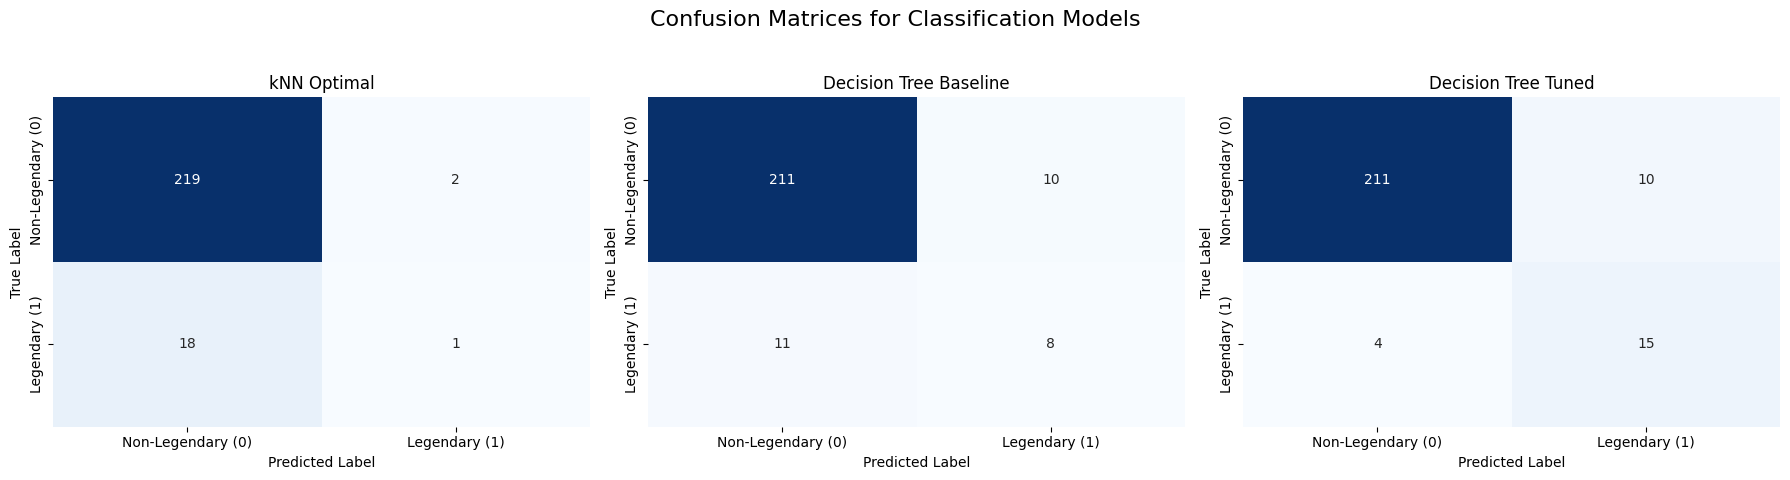

In [17]:
# This cell evaluates the three models using the confusion matrix metric.

print("\n--- Model Evaluation using Confusion Matrix ---")

# --- Evaluation for kNN_Optimal ---
y_test_knn = test_data['y_test_2_features']
y_pred_knn = predictions['kNN_Optimal']
cm_knn = confusion_matrix(y_test_knn, y_pred_knn)
report_knn = classification_report(y_test_knn, y_pred_knn, output_dict=True, zero_division=0)

print("\nEvaluation for kNN_Optimal:")
print("Confusion Matrix:")
print(cm_knn)
print("\nClassification Report:")
print(classification_report(y_test_knn, y_pred_knn, zero_division=0))

# --- Evaluation for DT_Baseline ---
y_test_dt_baseline = test_data['y_test_2_features']
y_pred_dt_baseline = predictions['DT_Baseline']
cm_dt_baseline = confusion_matrix(y_test_dt_baseline, y_pred_dt_baseline)
report_dt_baseline = classification_report(y_test_dt_baseline, y_pred_dt_baseline, output_dict=True, zero_division=0)

print("\nEvaluation for Decision Tree_Baseline:")
print("Confusion Matrix:")
print(cm_dt_baseline)
print("\nClassification Report:")
print(classification_report(y_test_dt_baseline, y_pred_dt_baseline, zero_division=0))

# --- Evaluation for DT_Tuned ---
y_test_dt_tuned = test_data['y_test_full_features']
y_pred_dt_tuned = predictions['DT_Tuned']
cm_dt_tuned = confusion_matrix(y_test_dt_tuned, y_pred_dt_tuned)
report_dt_tuned = classification_report(y_test_dt_tuned, y_pred_dt_tuned, output_dict=True, zero_division=0)

print("\nEvaluation for Decision Tree_Tuned:")
print("Confusion Matrix:")
print(cm_dt_tuned)
print("\nClassification Report:")
print(classification_report(y_test_dt_tuned, y_pred_dt_tuned, zero_division=0))

# --- Summary and Visualization ---
print("\n--- Summary of Model Performance (Accuracy) ---")
summary_df = pd.DataFrame({
    'Model': ['kNN_Optimal ', 'Decision Tree_Baseline', 'Decision Tree_Tuned'],
    'Accuracy': [
        report_knn['accuracy'],
        report_dt_baseline['accuracy'],
        report_dt_tuned['accuracy']
    ],
    'Features Used': ['Attack, Defense', 'Attack, Defense', 'All Base Stats, Gen, Total']
})
print(summary_df.to_markdown(index=False))

# Visualization of Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices for Classification Models', fontsize=16)

titles = ['kNN Optimal', 'Decision Tree Baseline', 'Decision Tree Tuned']
cms = [cm_knn, cm_dt_baseline, cm_dt_tuned]

for i, cm in enumerate(cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Non-Legendary (0)', 'Legendary (1)'],
                yticklabels=['Non-Legendary (0)', 'Legendary (1)'],
                ax=axes[i])
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()




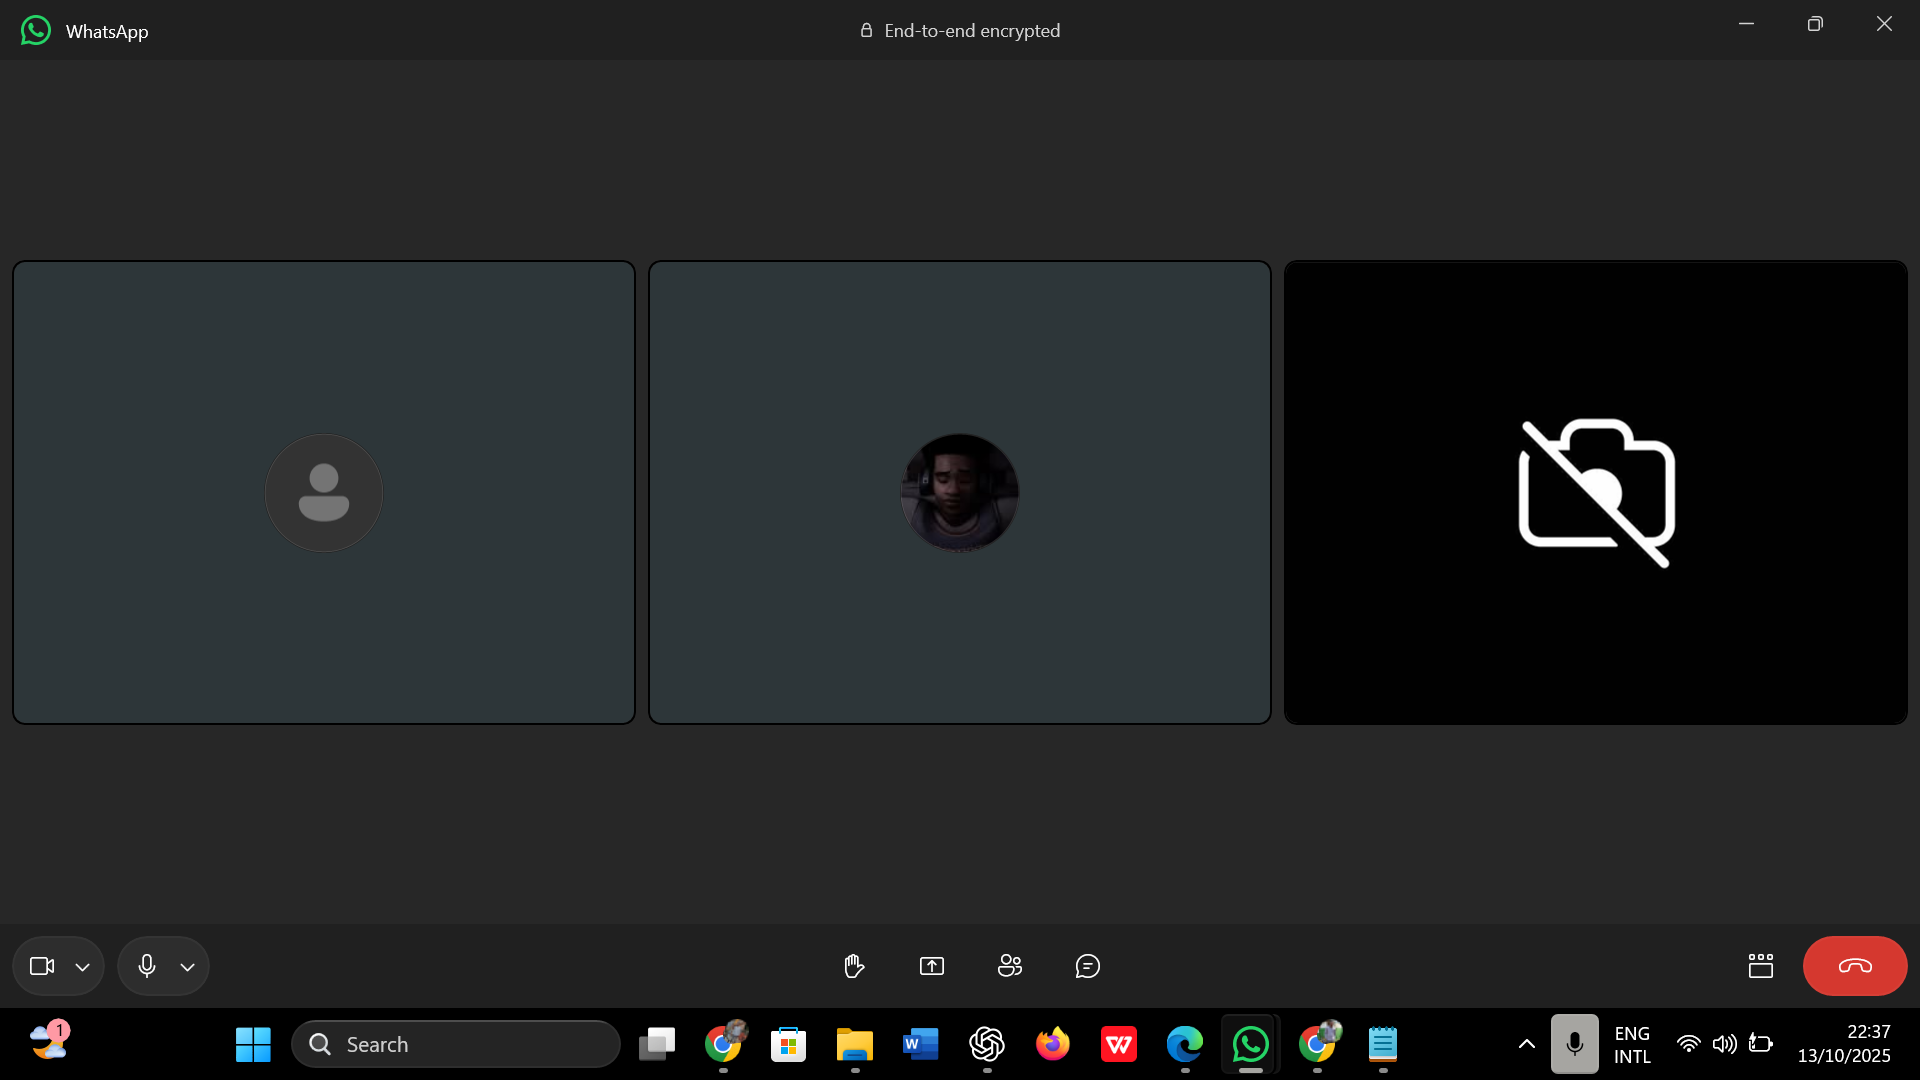